# Cora Dataset Analysis

## Objective

This project investigates the structural properties of the **Cora citation network** through five guiding research questions:

1. Is academic knowledge distributed democratically, or dominated by a small number of influential works?
2. How do milestone papers compare to literature reviews in terms of their network behavior?
3. Does scientific progress occur within isolated disciplinary communities, or through cross-disciplinary interactions?
4. If the network is composed of segregated communities, what mechanisms enable global information flow?
5. What happens when a novel idea is introduced into the network?

The goal is to address these questions through a systematic analysis of the Cora dataset and its underlying graph structure.

## Network Setup
We begin by configuring the network environment for the analysis. This includes importing all the required libraries used throughout the project, loading the Cora dataset, and constructing the corresponding directed graph representation.

In [55]:
# STANDARD PYTHON LIBRARIES (Built-in)
from collections import Counter
import json
import threading
import webbrowser
import http.server
import socketserver

# DATA SCIENCE & GRAPH ANALYSIS (Core Math)
import networkx as nx
import networkx.algorithms.community as nx_comm
import numpy as np
import pandas as pd

# MACHINE LEARNING METRICS (Validation)
from sklearn.metrics import adjusted_rand_score

# PLOTTING & VISUALIZATION (Static Graphics)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [43]:
# Loading and configuration of the cites bdf file (Edges)
cites = pd.read_csv("./data/cora.cites", sep="\t", header=None, names=["target", "source"]) # type: ignore

# Loading file content (Nodes and Attributes)
content = pd.read_csv("./data/cora.content", sep="\t", header=None) # type: ignore

In [44]:
# Directed Graph initialization
G = nx.DiGraph()
G.add_edges_from(cites[['source', 'target']].values)

# Extraction os node IDs and labels
paper_ids = content[0] # type: ignore
labels = content.iloc[:, -1] # type: ignore
label_dict = dict(zip(paper_ids, labels))

# Align graph nodes with dataset nodes
# Ensure isolated papers (nodes with no citations) are included in the graph
G.add_nodes_from(paper_ids)

# Assign the "field" attribute to each node
nx.set_node_attributes(G, label_dict, "field")

# Remove nodes that appear in the edge list but have no metadata in the content file ("ghost" nodes)
nodes_without_field = [n for n, attr in G.nodes(data=True) if "field" not in attr]
if len(nodes_without_field) > 0:
    print(f"Warning: Removing {len(nodes_without_field)} ghost nodes found in edges but missing in content.")
    G.remove_nodes_from(nodes_without_field)

# Final Check!
print(f"Network is Ready! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Network is Ready! Nodes: 2708 | Edges: 5429


In [60]:
# ==========================================
# Graph configuration
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#34495e'
plt.rcParams['ytick.color'] = '#34495e'

# --- Common parameters ---
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['axes.edgecolor'] = '#bdc3c7'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#ecf0f1'
plt.rcParams['grid.linewidth'] = 0.8

# --- Helper Function for Log-Log Scalar Formatting ---
def format_log_axes(ax_log):
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')

    # Force standard integer/decimal formatting instead of scientific notation (10^n)
    ax_log.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax_log.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax_log.ticklabel_format(style='plain', axis='both')

    # Configure clean grid and clean axes spines (remove top/right borders)
    ax_log.grid(True, which="both", ls="-", color='#ecf0f1', linewidth=0.8)
    ax_log.set_facecolor('#ffffff')
    for spine_for in ['top', 'right']:
        ax_log.spines[spine_for].set_visible(False)
    ax_log.spines['left'].set_color('#bdc3c7')
    ax_log.spines['bottom'].set_color('#bdc3c7')

## 1) Is Academic Knowledge Democratic or Oligarchic?
Is the citation structure distributed equitably among papers, or is it dominated by a small elite of academic "barons"?

### Network Density & Sparsity

In [46]:
# Getting graph statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Max possible edges in a Directed Graph: L * (L - 1) with L = |V|
max_possible_edges = num_nodes * (num_nodes - 1)
density = nx.density(G)
sparsity = 1.0 - density

print("=== GLOBAL NETWORK DENSITY & SPARSITY REPORT ===")
pd.DataFrame({
    "Metric Description": [
        "Total Papers (Nodes, V)",
        "Total Citations (Edges, E)",
        "Maximum Theoretical Edges",
        "Network Density (Friction)",
        "Network Sparsity (Empty Links)"
    ],
    "Value": [
        num_nodes,
        num_edges,
        max_possible_edges,
        density,
        sparsity
    ],
    "Percentage / Interpretation": [
        "100% of dataset population",
        "Observed connections",
        "L * (L - 1) upper bound (L = |V|)",
        f"{density * 100:.4f}% of maximum capacity",
        f"{sparsity * 100:.4f}% of potential links are empty"
    ]
}).style.format({
    "Value": lambda x: f"{x:,.0f}" if x >= 1 else f"{x:,.6f}"
}).hide(axis='index')

=== GLOBAL NETWORK DENSITY & SPARSITY REPORT ===


Metric Description,Value,Percentage / Interpretation
"Total Papers (Nodes, V)","2,708",100% of dataset population
"Total Citations (Edges, E)","5,429",Observed connections
Maximum Theoretical Edges,"7,330,556",L * (L - 1) upper bound (L = |E|)
Network Density (Friction),0.000741,0.0741% of maximum capacity
Network Sparsity (Empty Links),0.999259,99.9259% of potential links are empty


### In-Degree Statistics

In [47]:
# Getting in-degree
in_degree_dict = dict(G.in_degree())
in_values = np.array(list(in_degree_dict.values()))

# Calculating stats on in-degree
mean_in = np.mean(in_values)
std_in = np.std(in_values)
min_in = np.min(in_values)
max_in = np.max(in_values)

In [48]:
print("=== EMPIRICAL IN-DEGREE STATISTICS ===")
pd.DataFrame({
    "Statistical Metric": ["Mean Citations", "Standard Deviation", "Minimum Citations", "Maximum Citations"],
    "Value": [mean_in, std_in, float(min_in), float(max_in)],
    "Structural Meaning": [
        "Average baseline visibility of a paper",
        "Dispersion and heterogeneity of the network",
        "Uncited or completely isolated papers",
        "The absolute most influential paper (Baron)"
    ]
})

=== EMPIRICAL IN-DEGREE STATISTICS ===


,Statistical Metric,Value,Structural Meaning
0,Mean Citations,2.004801,Average baseline visibility of a paper
1,Standard Deviation,5.218170,Dispersion and heterogeneity of the network
2,Minimum Citations,0.000000,Uncited or completely isolated papers
3,Maximum Citations,166.000000,The absolute most influential paper (Baron)


In [49]:
# Calculating percentile to get the threshold needed to access the elite part of the network
hub_threshold = np.percentile(in_values, 99)
num_hubs = np.sum(in_values >= hub_threshold)
pct_hubs = (num_hubs / len(in_values)) * 100

print("\n=== THE ACADEMIC ARISTOCRACY (99th Percentile Isolation) ===")
pd.DataFrame({
    "Elite Feature": ["99th Percentile Threshold", "Elite Hubs Count", "Network Population Share"],
    "Value": [hub_threshold, float(num_hubs), pct_hubs],
    "Interpretation": [
        "Minimum citations required to enter the aristocracy",
        f"Papers with >= {hub_threshold:.1f} citations",
        "Percentage of nodes dominating the citation market"
    ]
})


=== THE ACADEMIC ARISTOCRACY (99th Percentile Isolation) ===


,Elite Feature,Value,Interpretation
0,99th Percentile Threshold,18.000000,Minimum citations required to enter the aristo...
1,Elite Hubs Count,29.000000,Papers with >= 18.0 citations
2,Network Population Share,1.070901,Percentage of nodes dominating the citation ma...


### Most Important Papers (Top In-Degree)

In [8]:
# Getting top cited papers
top_papers = sorted(in_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
total_citations = sum(in_degree_dict.values())

print("=== TOP 10 Most cited papers ===\n")
pd.DataFrame([
    {
        "Paper ID": paper,
        "Citations (In-Degree)": deg,
        "Academic Field": G.nodes[paper].get('field', 'unknown'),
        "Share of Total Network Citations": (deg / total_citations) * 100
    }
    for paper, deg in top_papers
])

=== TOP 10 Most cited papers ===



,Paper ID,Citations (In-Degree),Academic Field,Share of Total Network Citations
0,35,166,Genetic_Algorithms,3.057653
1,6213,76,Reinforcement_Learning,1.399889
2,1365,74,Neural_Networks,1.363050
3,3229,61,Neural_Networks,1.123596
4,114,42,Reinforcement_Learning,0.773623
5,910,41,Neural_Networks,0.755204
6,4330,38,Probabilistic_Methods,0.699945
7,1272,32,Theory,0.589427
8,3231,32,Theory,0.589427
9,4584,32,Reinforcement_Learning,0.589427


### CCDF tail analysis

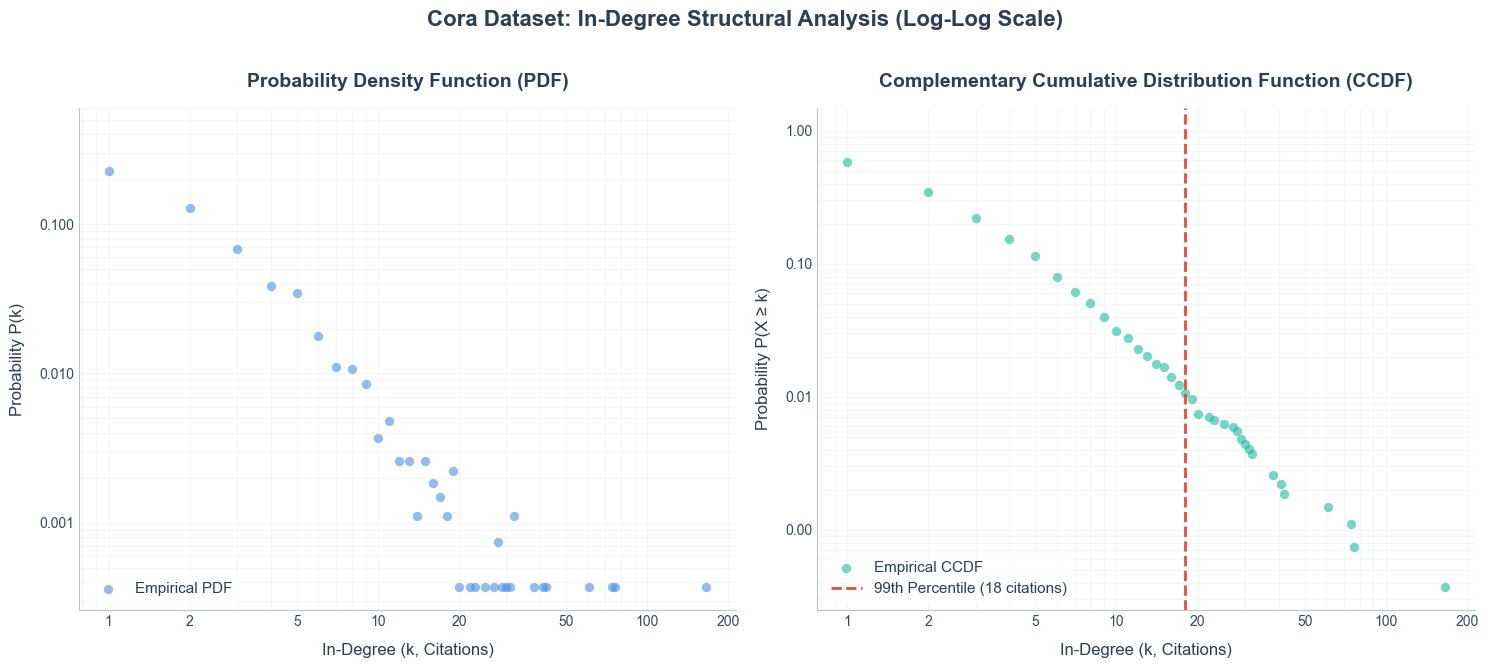

In [65]:
# Count frequencies of unique in-degree values
in_counts = Counter(in_values)
in_degrees_unique = np.array(sorted(in_counts.keys()))
in_degrees_freq = np.array([in_counts[d] for d in in_degrees_unique])

# Compute Probability Density Function (PDF)
in_pdf = in_degrees_freq / len(in_values)

# Compute Complementary Cumulative Distribution Function (CCDF): P(X >= k)
in_ccdf = np.cumsum(in_degrees_freq[::-1])[::-1] / len(in_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#ffffff')

# --- Subplot 1: Probability Density Function (PDF) ---
axes[0].scatter(in_degrees_unique, in_pdf, color='#4a90e2', alpha=0.6, s=45, linewidths=0, label='Empirical PDF')
format_log_axes(axes[0])
axes[0].set_title('Probability Density Function (PDF)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
axes[0].set_xlabel('In-Degree (k, Citations)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Probability P(k)', fontsize=12, labelpad=10)
axes[0].legend(fontsize=11, loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='none')

# --- Subplot 2: Complementary Cumulative Distribution Function (CCDF) ---
axes[1].scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=45, linewidths=0, label='Empirical CCDF')

# Visual marker for the 99th percentile (Oligarchy threshold)
axes[1].axvline(x=hub_threshold, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'99th Percentile ({int(hub_threshold)} citations)')
format_log_axes(axes[1])
axes[1].set_title('Complementary Cumulative Distribution Function (CCDF)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
axes[1].set_xlabel('In-Degree (k, Citations)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=12, labelpad=10)
axes[1].legend(fontsize=11, loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='none')

# Override x-ticks to display meaningful structural integer values
for ax in axes:
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# --- Global Layout & Figure Export ---
plt.suptitle('Cora Dataset: In-Degree Structural Analysis (Log-Log Scale)', fontsize=16, fontweight='bold', color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('./images/pdf_cdf_in_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Baseline check (Erdős-Rényi Graph)

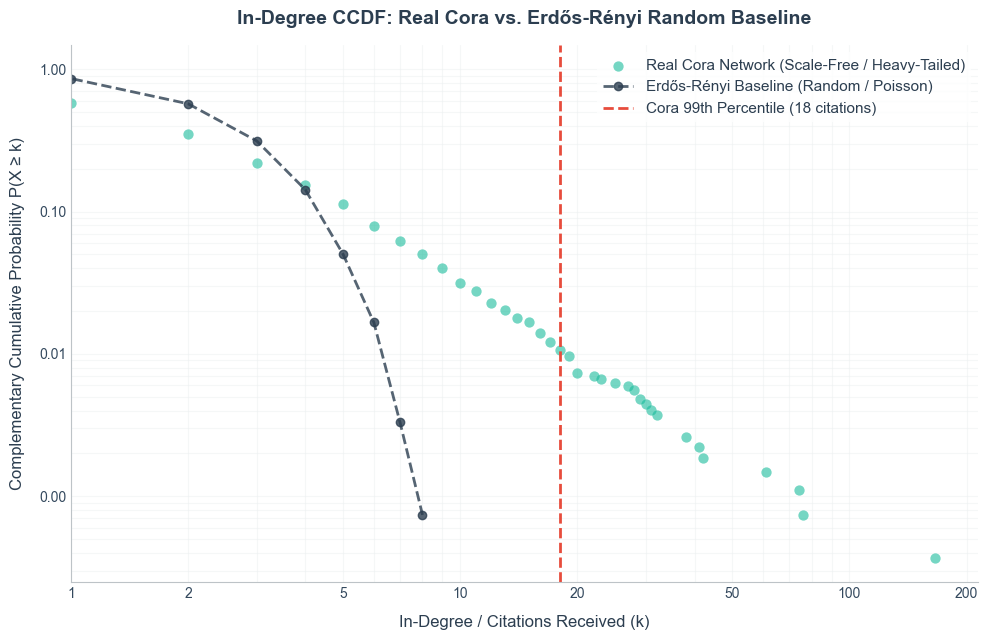

In [66]:
# Generate Erdős-Rényi Baseline Model
p_edge = num_edges / (num_nodes * (num_nodes - 1)) # Probability of an edge: E / (V * (V-1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)

# Extract Erdős-Rényi In-Degrees
erdos_values = np.array([d for n, d in G_erdos.in_degree()])
erdos_counts = Counter(erdos_values)
erdos_degrees_unique = np.array(sorted(erdos_counts.keys()))
erdos_ccdf = np.array([np.sum(erdos_values >= k) / num_nodes for k in erdos_degrees_unique])

# Plotting the Scientific Comparison
plt.figure(figsize=(10, 6.5), facecolor='#ffffff')

# Plot Cora (Scale-Free Power Law) - Teal/Verde Acqua scatter points
plt.scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=55, linewidths=0,
            label='Real Cora Network (Scale-Free / Heavy-Tailed)')

# Plot Erdős-Rényi (Poisson / Random) - Black dashed line with markers
plt.plot(erdos_degrees_unique, erdos_ccdf, color='#2c3e50', linestyle='--', linewidth=2,
         marker='o', markersize=6, alpha=0.8, label='Erdős-Rényi Baseline (Random / Poisson)')

# Highlight the 99th Percentile of Cora - Coral Red vertical line
plt.axvline(x=hub_threshold, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Cora 99th Percentile ({int(hub_threshold)} citations)')

ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

# Force real integer formatting on axes instead of standard 10^n scientific notation
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='both')

# Override x-ticks to display meaningful structural values
ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# Clean grid lines and remove unnecessary top/right spines
ax.grid(True, which="both", ls="-", color='#ecf0f1', linewidth=0.8)
ax.set_facecolor('#ffffff')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Labels, Legend & Figure Export
plt.title('In-Degree CCDF: Real Cora vs. Erdős-Rényi Random Baseline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('In-Degree / Citations Received (k)', fontsize=12, labelpad=10)
plt.ylabel('Complementary Cumulative Probability P(X ≥ k)', fontsize=12, labelpad=10)
plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

plt.xlim(left=1)
plt.tight_layout()

plt.savefig('./images/pdf_cdf_in_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### PageRank Centrality

In [80]:
# Getting pagerank scores
pagerank_scores = nx.pagerank(G)
hubs_scores, authorities_scores = nx.hits(G, max_iter=500)

# Build a SINGLE, master DataFrame to eliminate all structural redundancies
df_master = pd.DataFrame({
    "Paper ID": list(G.nodes()),
    "Academic Field": [G.nodes[n].get("field", "unknown") for n in G.nodes()],
    "In-Degree (Citations)": [G.in_degree(n) for n in G.nodes()],
    "Out-Degree (References)": [G.out_degree(n) for n in G.nodes()],
    "PageRank": [pagerank_scores[n] for n in G.nodes()],
    "Authority Score (HITS)": [authorities_scores[n] for n in G.nodes()],
    "Hub Score (HITS)": [hubs_scores[n] for n in G.nodes()]
})

# Calculate Relative Structural Ranks
df_master["PR Rank"] = df_master["PageRank"].rank(ascending=False, method="min").astype(int)
df_master["Degree Rank"] = df_master["In-Degree (Citations)"].rank(ascending=False, method="min").astype(int)
df_master["Rank Shift (PR vs Deg)"] = df_master["Degree Rank"] - df_master["PR Rank"]

print("\n=== STRUCTURAL PRESTIGE REPORT: TOP 10 PAPERS BY PAGERANK ===")
# Ordering and isolating top PageRank nodes
column_order_pr = ["PR Rank", "Paper ID", "PageRank", "In-Degree (Citations)", "Degree Rank", "Rank Shift (PR vs Deg)", "Academic Field"]
df_top_pr = df_master.sort_values(by="PageRank", ascending=False).head(10)[column_order_pr]
display(df_top_pr.style.format({"PageRank": "{:.6f}".format}).hide(axis='index'))


=== STRUCTURAL PRESTIGE REPORT: TOP 10 PAPERS BY PAGERANK ===


PR Rank,Paper ID,PageRank,In-Degree (Citations),Degree Rank,Rank Shift (PR vs Deg),Academic Field
1,35,0.025159,166,1,0,Genetic_Algorithms
2,15429,0.024755,19,21,19,Theory
3,10177,0.024019,15,39,36,Theory
4,210871,0.011900,13,49,45,Genetic_Algorithms
5,210872,0.009879,6,168,163,Genetic_Algorithms
6,82920,0.008861,23,18,12,Genetic_Algorithms
7,1365,0.008127,74,3,-4,Neural_Networks
8,4584,0.007806,32,8,0,Reinforcement_Learning
9,887,0.007400,27,16,7,Genetic_Algorithms
10,643221,0.007000,16,34,24,Probabilistic_Methods


## 2) Milestone Papers vs. Literature Reviews: How Do They Behave?
How can we mathematically distinguish a groundbreaking paper that founded a discipline from a paper that simply did an excellent job summarizing existing literature?

### Out-Degree Statistics

In [11]:
# Degree Computations (In VS Out)
out_values = np.array([d for n, d in G.out_degree()])

print("=== DIRECTIONAL DEGREE ASYMMETRY ANALYSIS ===")
pd.DataFrame({
    "Directional Metric": [
        "Mean (Average)",
        "Standard Deviation (Std)",
        "Minimum",
        "Maximum"
    ],
    "In-Degree (Citations Received)": [
        np.mean(in_values),
        np.std(in_values),
        float(np.min(in_values)),
        float(np.max(in_values))
    ],
    "Out-Degree (References Made)": [
        np.mean(out_values),
        np.std(out_values),
        float(np.min(out_values)),
        float(np.max(out_values))
    ]
})

=== DIRECTIONAL DEGREE ASYMMETRY ANALYSIS ===


,Directional Metric,In-Degree (Citations Received),Out-Degree (References Made)
0,Mean (Average),2.004801,2.004801
1,Standard Deviation (Std),5.218170,1.478419
2,Minimum,0.000000,0.000000
3,Maximum,166.000000,5.000000


### In-Degree vs Out-Degree CCDF Comparison

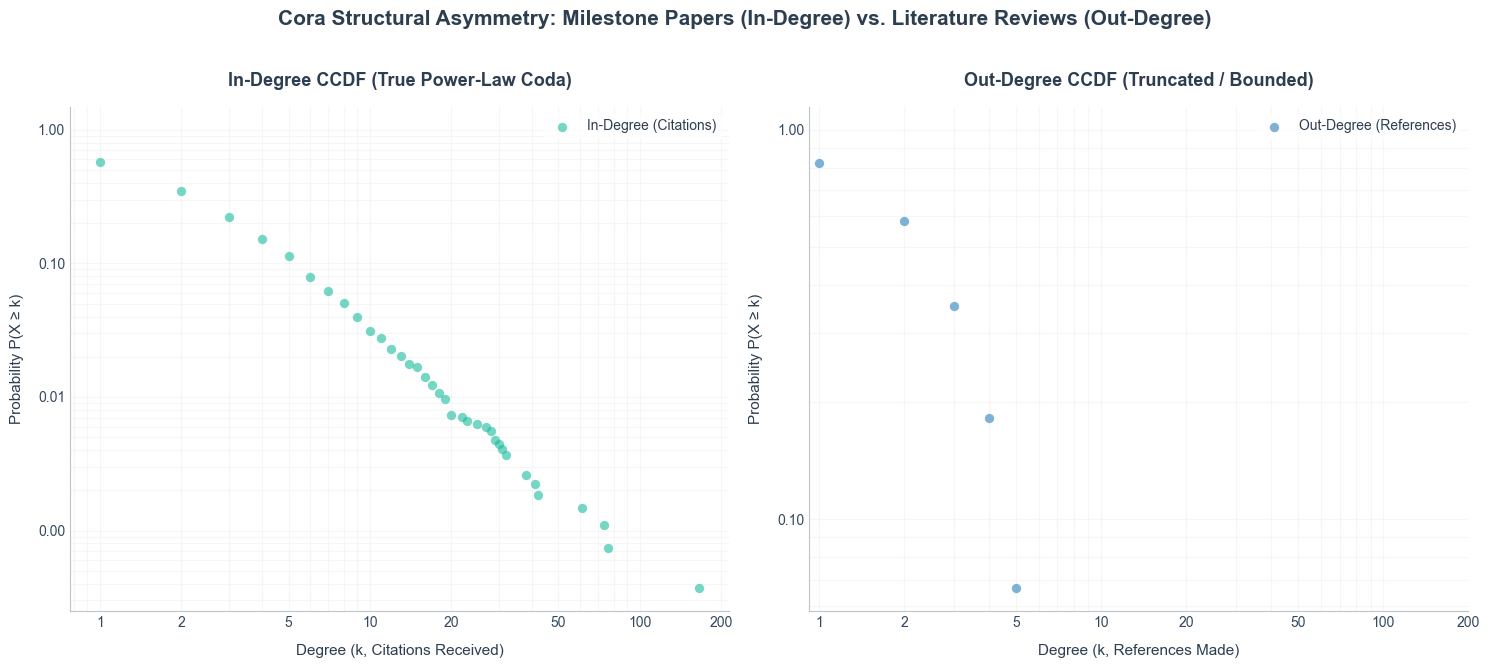

In [68]:
# Compute CCDF for Out-Degree
out_counts = Counter(out_values)
out_deg_unique = np.array(sorted(out_counts.keys()))
out_degrees_freq = np.array([out_counts[d] for d in out_deg_unique])
out_ccdf = np.cumsum(out_degrees_freq[::-1])[::-1] / len(out_values)

# Plotting: The Structural Asymmetry (In vs Out CCDF)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#ffffff')

# --- SUBPLOT 1: In-Degree CCDF (Authorities) ---
axes[0].scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=45,
                linewidths=0, label='In-Degree (Citations)')
format_log_axes(axes[0])
axes[0].set_title('In-Degree CCDF (True Power-Law Coda)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Degree (k, Citations Received)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Probability P(X ≥ k)', fontsize=11, labelpad=10)
axes[0].legend(fontsize=10, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

# --- SUBPLOT 2: Out-Degree CCDF (Hubs) ---
axes[1].scatter(out_deg_unique, out_ccdf, color='#2980b9', alpha=0.6, s=45,
                linewidths=0, label='Out-Degree (References)')
format_log_axes(axes[1])
axes[1].set_title('Out-Degree CCDF (Truncated / Bounded)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Degree (k, References Made)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=11, labelpad=10)
axes[1].legend(fontsize=10, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

# Override x-ticks to display identical meaningful structural integer values on both subplots
for ax in axes:
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# --- Global Infographics Title ---
plt.suptitle('Cora Structural Asymmetry: Milestone Papers (In-Degree) vs. Literature Reviews (Out-Degree)',
             fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)

plt.tight_layout()

# Save high-resolution comparative graph for LaTeX integration
plt.savefig('./images/cora_hits_asymmetry.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Hubs

In [78]:
degree_authorities = [node for node, deg in G.in_degree() if deg >= hub_threshold]
num_auths = len(degree_authorities)

top_auth = max(G.in_degree(), key=lambda x: x[1])
top_node_id = top_auth[0]
edge_share = (top_auth[1] / num_edges) * 100

auth_fields = [G.nodes[node].get('field', 'Unknown') for node in degree_authorities]
field_counts = Counter(auth_fields)

# --- Render Profile Tables ---
print("=== AUTHORITY ELITE DETECTION (Top 1% Most Cited) ===")
df_elite_report = pd.DataFrame({
    "Detection Metric": ["In-Degree Threshold (99th Percentile)", "Elite Population Count", "Total Network Population", "Elite Proportion"],
    "Value": [f"{hub_threshold:.1f} citations", f"{num_auths} papers", f"{num_nodes} papers", f"{(num_auths / num_nodes) * 100:.2f}% of network"]
})
display(df_elite_report.style.hide(axis='index'))

print("\n=== THE ULTIMATE NETWORK AUTHORITY PROFILE ===")
df_top_profile = pd.DataFrame({
    "Property": ["Paper ID", "Total Citations Received", "Academic Field", "Global Edge Market Share"],
    "Value": [str(top_node_id), f"{top_auth[1]}", G.nodes[top_node_id].get('field', 'Unknown'), f"{edge_share:.2f}% of all network edges"]
})
display(df_top_profile.style.hide(axis='index'))

print("\n=== FIELD DISTRIBUTION AMONG THE ARISTOCRACY ===")
df_fields_elite = pd.DataFrame([
    {"Academic Field": field, "Elite Count": count, "Share of Elite (%)": (count / num_auths) * 100}
    for field, count in field_counts.most_common()
])
display(df_fields_elite.style.format({"Share of Elite (%)": "{:.2f}%".format}).hide(axis='index'))

=== AUTHORITY ELITE DETECTION (Top 1% Most Cited) ===


Detection Metric,Value
In-Degree Threshold (99th Percentile),18.0 citations
Elite Population Count,29 papers
Total Network Population,2708 papers
Elite Proportion,1.07% of network



=== THE ULTIMATE NETWORK AUTHORITY PROFILE ===


Property,Value
Paper ID,35
Total Citations Received,166
Academic Field,Genetic_Algorithms
Global Edge Market Share,3.06% of all network edges



=== FIELD DISTRIBUTION AMONG THE ARISTOCRACY ===


Academic Field,Elite Count,Share of Elite (%)
Theory,9,31.03%
Neural_Networks,8,27.59%
Genetic_Algorithms,4,13.79%
Reinforcement_Learning,4,13.79%
Probabilistic_Methods,2,6.90%
Rule_Learning,1,3.45%
Case_Based,1,3.45%


## 3) Does Science Advance in Isolated Silos or via Cross-Disciplinary Contamination?
Do scientists exclusively cite peers who share their exact sub-field, or do they actively browse and integrate external disciplines?

### Attribute Assortativity Coefficient ($r$)

In [19]:
assortativity_field = nx.attribute_assortativity_coefficient(G, "field")

if assortativity_field > 0.3:
    regime = "Strong Assortativity (Homophily)"
    desc = "Cultural Silos: Papers strongly prefer to cite within their own academic field. Knowledge is highly segregated."
elif assortativity_field > 0.1:
    regime = "Moderate Assortativity"
    desc = "Visible Discipline Borders: In-field citations are preferred, but cross-disciplinary dialogue is present."
elif assortativity_field < -0.1:
    regime = "Disassortativity (Heterophily)"
    desc = "Interdisciplinary Bridges: Papers preferentially cite outside their own field, suggesting a complementary ecosystem."
else:
    regime = "Neutral / Random Mixing"
    desc = "Topology-Blind Citations: The field category does not mathematically dictate or restrict citation patterns."

assortativity_data = {
    "Network Dimension": ["Target Attribute", "Assortativity Coefficient ($r$)", "Mixing Regime", "Structural Interpretation"],
    "Value": ["field (Academic Subject)", f"{assortativity_field:.4f}", regime, desc]
}

print("=== COGNITIVE HOMOPHILY REPORT: THE ASSORTATIVITY INDEX ===")
pd.DataFrame(assortativity_data)

=== COGNITIVE HOMOPHILY REPORT: THE ASSORTATIVITY INDEX ===


,Network Dimension,Value
0,Target Attribute,field (Academic Subject)
1,Assortativity Coefficient ($r$),0.7755
2,Mixing Regime,Strong Assortativity (Homophily)
3,Structural Interpretation,Cultural Silos: Papers strongly prefer to cite...


### Attribute Mixing Matrix

In [20]:
# Mixing matrix preparation
fields_list = sorted(list(set(nx.get_node_attributes(G, "field").values())))
mixing_matrix = nx.attribute_mixing_matrix(G, "field", mapping={f: i for i, f in enumerate(fields_list)})
mixing_df = pd.DataFrame(mixing_matrix, index=fields_list, columns=fields_list)

### Mixing Matrix Heatmap

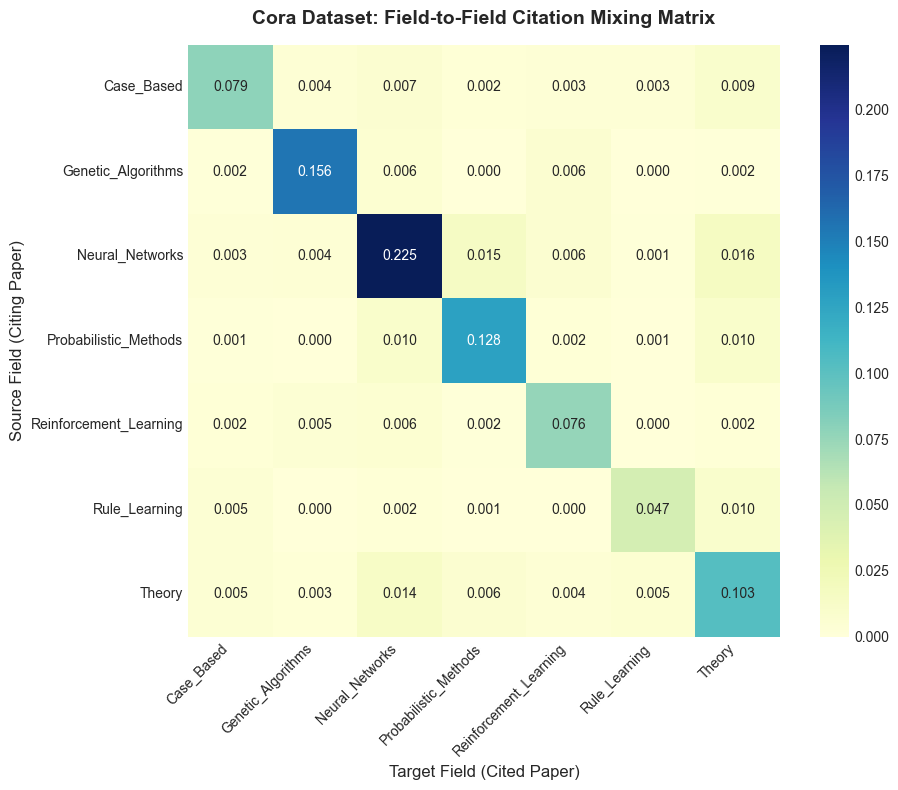

In [21]:
# --- 3. Visualize the Mixing Matrix via Heatmap ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))
sns.heatmap(mixing_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, square=True)
plt.title("Cora Dataset: Field-to-Field Citation Mixing Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Target Field (Cited Paper)", fontsize=12)
plt.ylabel("Source Field (Citing Paper)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('./images/cora_assortativity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Analytical Homophily Test ($\rho \ll 2pq$)

In [22]:
cross_edges_count = sum(
    1 for u, v in G.edges()
    if G.nodes[u].get("field") != G.nodes[v].get("field")
)

rho = cross_edges_count / num_edges

node_fields = [G.nodes[n].get("field") for n in G.nodes() if G.nodes[n].get("field") is not None]
field_counts = pd.Series(node_fields).value_counts()
field_probabilities = field_counts / len(node_fields)

expected_cross_fraction = 1.0 - np.sum(field_probabilities ** 2)
ratio = rho / expected_cross_fraction

if rho < expected_cross_fraction:
    verdict = "HOMOPHILY CONFIRMED"
    interpretation = f"The actual cross-field citation rate is suppressed, reaching only {ratio:.2%} of what random chance predicts."
else:
    verdict = "NO HOMOPHILY / HETEROPHILY"
    interpretation = "Citations cross disciplinary boundaries as much as or more than expected by pure chance."

homophily_test_data = {
    "Analytical Metric": [
        "Observed Cross-Edges Fraction (ρ)",
        "Expected Random Cross Fraction ($1 - \\sum p_i^2$)",
        "Suppression Ratio (Observed / Expected)",
        "Statistical Verdict",
        "Physical Meaning"
    ],
    "Value / Result": [
        f"{rho:.4%}",
        f"{expected_cross_fraction:.4%}",
        f"{ratio:.4f}",
        verdict,
        interpretation
    ]
}

df_homophily_test = pd.DataFrame(homophily_test_data)

print("=== ANALYTICAL HOMOPHILY TEST: EMPIRICAL VS NULL MODEL ===")
display(df_homophily_test)

=== ANALYTICAL HOMOPHILY TEST: EMPIRICAL VS NULL MODEL ===


,Analytical Metric,Value / Result
0,Observed Cross-Edges Fraction (ρ),18.6222%
1,Expected Random Cross Fraction ($1 - \sum p_i^2$),82.0432%
2,Suppression Ratio (Observed / Expected),0.2270
3,Statistical Verdict,HOMOPHILY CONFIRMED
4,Physical Meaning,The actual cross-field citation rate is suppre...


## 4) If the Network is Segregated into Silos, How Does Information Ever Circulate Globally?
How can we reconcile a network heavily fractured into isolated academic disciplines with the Small-World phenomenon, which states that any two papers are separated by only a few steps? Who acts as the structural glue?

### Connected Components and Giant Component

In [23]:
# Getting the giant component
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))

largest_scc_nodes = max(scc, key=len)
largest_wcc_nodes = max(wcc, key=len)

largest_scc_size = len(largest_scc_nodes)
largest_wcc_size = len(largest_wcc_nodes)

print("=== MACROSCOPIC CONNECTIVITY: COMPONENT ANALYSIS ===")
pd.DataFrame({
    "Topology Type": [
        "Strongly Connected (SCC - Mutual Paths)",
        "Weakly Connected (WCC - Ignore Direction)"
    ],
    "Total Components Found": [len(scc), len(wcc)],
    "Giant Component Size (Nodes)": [largest_scc_size, largest_wcc_size],
    "Network Absorption Share": [
        f"{(largest_scc_size / num_nodes) * 100:.2f}%",
        f"{(largest_wcc_size / num_nodes) * 100:.2f}%"
    ]
})

=== MACROSCOPIC CONNECTIVITY: COMPONENT ANALYSIS ===


,Topology Type,Total Components Found,Giant Component Size (Nodes),Network Absorption Share
0,Strongly Connected (SCC - Mutual Paths),2526,13,0.48%
1,Weakly Connected (WCC - Ignore Direction),78,2485,91.77%


In [24]:
G_gcc_directed = G.subgraph(largest_wcc_nodes)
G_gcc_undirected = G_gcc_directed.to_undirected()

n_gcc = G_gcc_undirected.number_of_nodes()
e_gcc = G_gcc_undirected.number_of_edges()

print("\n=== GIANT CONNECTED COMPONENT (GCC) PROFILE ===")
print("Note: Graph direction removed to compute distance metrics (Diameter & Path Lengths)")
pd.DataFrame({
    "GCC Structural Property": [
        "Nodes Isolate in GCC ($N_{gcc}$)",
        "Edges in Undirected GCC ($E_{gcc}$)",
        "GCC Population Coverage",
        "Graph Connectivity Status"
    ],
    "Value / Metric": [
        f"{n_gcc:,}",
        f"{e_gcc:,}",
        f"{(n_gcc / num_nodes) * 100:.2f}% of total graph",
        "Sub-graph is now fully connected (Diameter ready)"
    ]
})


=== GIANT CONNECTED COMPONENT (GCC) PROFILE ===
Note: Graph direction removed to compute distance metrics (Diameter & Path Lengths)


,GCC Structural Property,Value / Metric
0,Nodes Isolate in GCC ($N_{gcc}$),"2,485"
1,Edges in Undirected GCC ($E_{gcc}$),"5,069"
2,GCC Population Coverage,91.77% of total graph
3,Graph Connectivity Status,Sub-graph is now fully connected (Diameter ready)


### Reciprocity

In [25]:
global_reciprocity = nx.overall_reciprocity(G)

reciprocal_pairs = set()
for u, v in G.edges():
    if u < v and G.has_edge(v, u):
        reciprocal_pairs.add((u, v))

reciprocal_list = list(reciprocal_pairs)
num_reciprocal_pairs = len(reciprocal_list)

print("=== GLOBAL NETWORK RECIPROCITY REPORT ===")
pd.DataFrame({
    "Metric": [
        "Global Reciprocity Coefficient",
        "Reciprocal Edge Pairs Count",
        "Total Directed Edges (E)",
        "Percentage of Reciprocal Links"
    ],
    "Value": [
        f"{global_reciprocity:.6f}",
        f"{num_reciprocal_pairs:,}",
        f"{G.number_of_edges():,}",
        f"{(num_reciprocal_pairs * 2 / G.number_of_edges()) * 100:.4f}%"
    ],
    "Structural Meaning": [
        "Probability that a random directed edge is mutually returned",
        "Absolute number of mutual citation loops (A <---> B)",
        "Global baseline of directed arrows in the network",
        "Share of connectivity dedicated to mutual interaction"
    ]
})

=== GLOBAL NETWORK RECIPROCITY REPORT ===


,Metric,Value,Structural Meaning
0,Global Reciprocity Coefficient,0.055627,Probability that a random directed edge is mut...
1,Reciprocal Edge Pairs Count,151,Absolute number of mutual citation loops (A <-...
2,Total Directed Edges (E),"5,429",Global baseline of directed arrows in the network
3,Percentage of Reciprocal Links,5.5627%,Share of connectivity dedicated to mutual inte...


In [26]:
if num_reciprocal_pairs > 0:
    sample_rows = []
    for u, v in reciprocal_list[:5]:
        field_u = G.nodes[u].get('field', 'Unknown')
        field_v = G.nodes[v].get('field', 'Unknown')
        same_field = "YES" if field_u == field_v else "NO (Cross-Disciplinary)"

        sample_rows.append({
            "Source ID": u,
            "Source Field": field_u,
            "Target ID": v,
            "Target Field": field_v,
            "Homophilic Pair?": same_field
        })
    df_sample = pd.DataFrame(sample_rows)
else:
    df_sample = pd.DataFrame(columns=["Status"], data=[["No reciprocal edges found in the network."]])

print("\n=== QUALITATIVE SAMPLE OF MUTUAL CITATIONS (First 5 Pairs) ===")
display(df_sample)


=== QUALITATIVE SAMPLE OF MUTUAL CITATIONS (First 5 Pairs) ===


,Source ID,Source Field,Target ID,Target Field,Homophilic Pair?
0,31769,Neural_Networks,67245,Neural_Networks,YES
1,16819,Probabilistic_Methods,643221,Probabilistic_Methods,YES
2,155736,Theory,155738,Theory,YES
3,14429,Probabilistic_Methods,73119,Probabilistic_Methods,YES
4,11326,Theory,11339,Theory,YES


### Average Shortest Path Length ($L_{real}$)

In [27]:
L_real = nx.average_shortest_path_length(G_gcc_undirected)
k_avg = (2 * e_gcc) / n_gcc
L_rand = np.log(n_gcc) / np.log(k_avg)

print("=== GLOBAL DISTANCE & NAVIGATION ANALYSIS ===")
print(f"GCC Average Degree ⟨k⟩: {k_avg:.4f}")
pd.DataFrame({
    "Network Architecture": [
        "Real Cora GCC (Empirical)",
        "Erdős-Rényi Baseline (Random)",
        "Structural Proximity Ratio ($L_{real} / L_{rand}$)"
    ],
    "Average Path Length ($L$)": [
        L_real,
        L_rand,
        L_real / L_rand
    ],
    "Topological Interpretation": [
        f"Average separation between any two papers in the main component.",
        f"Theoretical path length if links were wired completely at random.",
        f"Efficiency factor. Values close to 1.0 indicate optimal Small-World navigation."
    ]
})

=== GLOBAL DISTANCE & NAVIGATION ANALYSIS ===
GCC Average Degree ⟨k⟩: 4.0797


,Network Architecture,Average Path Length ($L$),Topological Interpretation
0,Real Cora GCC (Empirical),6.310999,Average separation between any two papers in t...
1,Erdős-Rényi Baseline (Random),5.560404,Theoretical path length if links were wired co...
2,Structural Proximity Ratio ($L_{real} / L_{ran...,1.134989,Efficiency factor. Values close to 1.0 indicat...


### Average Clustering Coefficient ($C_{real}$)

In [28]:
C_real = nx.average_clustering(G_gcc_undirected)
C_rand = k_avg / n_gcc
clustering_amplification = C_real / C_rand

print("=== LOCAL TRANSITIVITY & TRIADIC CLOSURE REPORT ===")
pd.DataFrame({
    "Network Topology": [
        "Real Cora GCC (Empirical)",
        "Erdős-Rényi Baseline (Random)",
        "Clustering Amplification ($C_{real} / C_{rand}$)"
    ],
    "Clustering Coefficient ($C$)": [
        C_real,
        C_rand,
        clustering_amplification
    ],
    "Topological Meaning": [
        "Probability that two papers cited by the same document are also connected to each other.",
        "Expected clustering if edge interconnections occurred purely by blind chance.",
        "The factor by which the real network exceeds random triadic closure. Crucial for Small-World verification."
    ]
})

=== LOCAL TRANSITIVITY & TRIADIC CLOSURE REPORT ===


,Network Topology,Clustering Coefficient ($C$),Topological Meaning
0,Real Cora GCC (Empirical),0.237636,Probability that two papers cited by the same ...
1,Erdős-Rényi Baseline (Random),0.001642,Expected clustering if edge interconnections o...
2,Clustering Amplification ($C_{real} / C_{rand}$),144.747756,The factor by which the real network exceeds r...


### Small-Worldness Index ($\sigma$)

In [29]:
gamma = C_real / C_rand
lam = L_real / L_rand
sigma = gamma / lam

is_small_world = sigma > 1.0 and gamma > 1.0 and abs(lam - 1.0) < 0.5

if is_small_world:
    verdict = "CONFIRMED (Strong Small-World Properties)"
    conclusion_text = (
        f"Cora is a Small-World network. High local cohesiveness (𝛾 >> 1) "
        f"coexists with global navigational efficiency (𝜆 ≈ 1). You can cross "
        f"the whole network in just {np.ceil(L_real):.0f} citation steps on average."
    )
else:
    verdict = "NOT RECOGNIZED"
    conclusion_text = "The network topological parameters do not satisfy the joint Humphries-Gurney criteria."

print("=== RATIOS & HUMPHRIES-GURNEY SMALL-WORLDNESS INDEX ===")
pd.DataFrame({
    "Small-World Metric": [
        "Clustering Ratio ($\\gamma = C_{real} / C_{rand}$)",
        "Path Length Ratio ($\\lambda = L_{real} / L_{rand}$)",
        "Small-Worldness Index ($\\sigma = \\gamma / \\lambda$)",
        "Empirical Verdict",
        "Topological Summary"
    ],
    "Calculated Value": [
        f"{gamma:.4f}",
        f"{lam:.4f}",
        f"{sigma:.4f}",
        verdict,
        conclusion_text
    ],
    "Theoretical Acceptance Threshold": [
        "𝛾 >> 1 (Massive local clustering amplification)",
        "𝜆 ≈ 1 (Logarithmic distance scalability)",
        "𝜎 > 1 (Formal Small-World validation)",
        "All 3 criteria must be simultaneously met",
        "Physical implication on scientific knowledge diffusion"
    ]
})

=== RATIOS & HUMPHRIES-GURNEY SMALL-WORLDNESS INDEX ===


,Small-World Metric,Calculated Value,Theoretical Acceptance Threshold
0,Clustering Ratio ($\gamma = C_{real} / C_{rand}$),144.7478,𝛾 >> 1 (Massive local clustering amplification)
1,Path Length Ratio ($\lambda = L_{real} / L_{ra...,1.1350,𝜆 ≈ 1 (Logarithmic distance scalability)
2,Small-Worldness Index ($\sigma = \gamma / \lam...,127.5323,𝜎 > 1 (Formal Small-World validation)
3,Empirical Verdict,CONFIRMED (Strong Small-World Properties),All 3 criteria must be simultaneously met
4,Topological Summary,Cora is a Small-World network. High local cohe...,Physical implication on scientific knowledge d...


### (Cora vs ER vs Configuration Model)

In [30]:
# Since baseline generation can be heavy, we compute basic undirected metrics for comparison
G_real_und = G.to_undirected()

# 1. Compute Real Network Metrics
metrics_real = {
    "Baseline Model": "Real Cora Network",
    "Nodes ($N$)": num_nodes,
    "Edges ($E$)": num_edges,
    "Avg Clustering ($C$)": nx.average_clustering(G_real_und),
    "Transitivity ($T$)": nx.transitivity(G_real_und),
    "Number of WCC": nx.number_weakly_connected_components(G),
    "Global Reciprocity ($r$)": nx.overall_reciprocity(G)
}

# --- 2. Baseline Model A: Erdős-Rényi Random Graph ---
p_edge = num_edges / (num_nodes * (num_nodes - 1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)
G_erdos_und = G_erdos.to_undirected()

metrics_erdos = {
    "Baseline Model": "Erdős-Rényi (Random)",
    "Nodes ($N$)": G_erdos.number_of_nodes(),
    "Edges ($E$)": G_erdos.number_of_edges(),
    "Avg Clustering ($C$)": nx.average_clustering(G_erdos_und),
    "Transitivity ($T$)": nx.transitivity(G_erdos_und),
    "Number of WCC": nx.number_weakly_connected_components(G_erdos),
    "Global Reciprocity ($r$)": nx.overall_reciprocity(G_erdos)
}

# --- 3. Baseline Model B: Directed Configuration Model ---
# This preserves the exact in-degree and out-degree sequences of Cora
in_deg_sequence = [d for n, d in G.in_degree()]
out_deg_sequence = [d for n, d in G.out_degree()]

G_config_multi = nx.directed_configuration_model(in_deg_sequence, out_deg_sequence, seed=42)
G_config = nx.DiGraph(G_config_multi)
G_config.remove_edges_from(nx.selfloop_edges(G_config))
G_config_und = G_config.to_undirected()

metrics_config = {"Baseline Model": "Configuration Model (Degree-Preserved)", "Nodes ($N$)": G_config.number_of_nodes(),
                  "Edges ($E$)": G_config_multi.number_of_edges(),
                  "Avg Clustering ($C$)": nx.average_clustering(G_config_und),
                  "Transitivity ($T$)": nx.transitivity(G_config_und),
                  "Number of WCC": nx.number_weakly_connected_components(G_config),
                  "Global Reciprocity ($r$)": nx.overall_reciprocity(G_config)}

# --- 4. Generate and Print the Comparison Table ---

print("=== BASELINE MODELS COMPARISON TABLE ===")
pd.DataFrame([metrics_real, metrics_erdos, metrics_config])

=== BASELINE MODELS COMPARISON TABLE ===


,Baseline Model,Nodes ($N$),Edges ($E$),Avg Clustering ($C$),Transitivity ($T$),Number of WCC,Global Reciprocity ($r$)
0,Real Cora Network,2708,5429,0.240673,0.093497,78,0.055627
1,Erdős-Rényi (Random),2708,5308,0.000547,0.000725,61,0.000377
2,Configuration Model (Degree-Preserved),2708,5429,0.004361,0.003139,13,0.000739


### Betweenness Centrality

In [31]:
betweenness = nx.betweenness_centrality(G)

rows = []
for node, score in betweenness.items():
    rows.append({
        "Node": node,
        "Betweenness": score,
        "In_degree": G.in_degree(node),
        "Field": G.nodes[node].get('field', 'unknown')
    })

pd.DataFrame(rows).sort_values("Field", ascending=False).head(10)

,Node,Betweenness,In_degree,Field
2217,128202,0.000000,0,Theory
1979,59626,0.000000,5,Theory
1131,23738,0.000242,15,Theory
1965,711527,0.000000,0,Theory
1266,1119471,0.000000,0,Theory
1267,12169,0.000000,3,Theory
1268,1059953,0.000000,0,Theory
1269,1106418,0.000000,0,Theory
2134,93755,0.000000,1,Theory
1270,1117249,0.000000,0,Theory


### Neighborhood Overlap (Granovetter Theory)

In [32]:
neighbors_dict = {n: set(G_real_und.neighbors(n)) for n in G_real_und.nodes()}

fields_dict = {n: G.nodes[n].get("field", "unknown") for n in G_real_und.nodes()}

edge_data = []
for u, v in G_real_und.edges():
    nu = neighbors_dict[u]
    nv = neighbors_dict[v]

    intersection_len = len(nu & nv)
    union_len = len(nu | nv) - 2  # Escludiamo u e v dall'unione

    overlap = intersection_len / union_len if union_len > 0 else 0.0

    edge_data.append({
        "overlap": overlap,
        "is_local_bridge": overlap == 0.0,
        "is_cross_field": fields_dict[u] != fields_dict[v]
    })

df_edges = pd.DataFrame(edge_data)

local_bridges_count = df_edges["is_local_bridge"].sum()

avg_overlap_inside = df_edges[df_edges["is_cross_field"] == False]["overlap"].mean()
avg_overlap_cross = df_edges[df_edges["is_cross_field"] == True]["overlap"].mean()

df_bridges = df_edges[df_edges["is_local_bridge"] == True]
cross_field_bridges_pct = df_bridges["is_cross_field"].mean() if len(df_bridges) > 0 else 0.0

In [33]:
print("=== TOPOLOGICAL STRUCTURE: NEIGHBORHOOD OVERLAP MAP ===")
pd.DataFrame({
    "Topological Metric": [
        "Total Undirected Edges ($E_{und}$)",
        "Local Bridges Detected (Overlap = 0)",
        "Local Bridges Share (%)"
    ],
    "Value": [
        f"{num_edges:,}",
        f"{local_bridges_count:,}",
        f"{(local_bridges_count / num_edges) * 100:.2f}%"
    ],
    "Granovetter Meaning": [
        "Total communication channels in the undirected layout.",
        "Links whose removal strictly increases the distance between their endpoints.",
        "The proportion of the network acting as purely structural shortcuts."
    ]
})

=== TOPOLOGICAL STRUCTURE: NEIGHBORHOOD OVERLAP MAP ===


,Topological Metric,Value,Granovetter Meaning
0,Total Undirected Edges ($E_{und}$),"5,429",Total communication channels in the undirected...
1,Local Bridges Detected (Overlap = 0),"2,434",Links whose removal strictly increases the dis...
2,Local Bridges Share (%),44.83%,The proportion of the network acting as purely...


In [34]:
print("\n=== GRANOVETTER'S WEAK TIES MATHEMATICAL VALIDATION ===")
pd.DataFrame({
    "Citation Tie Category": [
        "Same-Field Citations (Intra-Disciplinary)",
        "Cross-Field Citations (Inter-Disciplinary)",
        "Bridges Nature (Share of Interdisciplinarity among Local Bridges)"
    ],
    "Empirical Neighborhood Overlap": [
        f"{avg_overlap_inside:.4f}",
        f"{avg_overlap_cross:.4f}",
        f"{cross_field_bridges_pct:.2%}"
    ],
    "Theoretical Validation Verdict": [
        "STRONG TIES: High overlap. Dense local networks where everyone knows everyone.",
        "WEAK TIES: Low overlap. Links acting as structural conduits between distant groups.",
        "HIGH ECO-BRIDGING: Confirms if bridges are the ones holding different disciplines together."
    ]
})


=== GRANOVETTER'S WEAK TIES MATHEMATICAL VALIDATION ===


,Citation Tie Category,Empirical Neighborhood Overlap,Theoretical Validation Verdict
0,Same-Field Citations (Intra-Disciplinary),0.1283,STRONG TIES: High overlap. Dense local network...
1,Cross-Field Citations (Inter-Disciplinary),0.0541,WEAK TIES: Low overlap. Links acting as struct...
2,Bridges Nature (Share of Interdisciplinarity a...,25.84%,HIGH ECO-BRIDGING: Confirms if bridges are the...


## 5) If We Inject an Innovative Idea into the Network, What is Its Fate?
Does a newly published scientific concept diffuse like a wildfire across the entire academic ecosystem, or does it burn out instantly? How heavily does its survival depend on who introduces it?

### Louvain Community Detection

In [35]:
G_undirected = G.to_undirected()

louvain_partition = nx_comm.louvain_communities(G_undirected, seed=42)

communities = nx_comm.louvain_communities(G.to_undirected(), seed=42)

node_community = {}

for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

nx.set_node_attributes(G, node_community, "community")

modularity_score = nx_comm.modularity(G_undirected, louvain_partition)

print("=== COMMUNITY DETECTION (LOUVAIN ALGORITHM) ===")
print(f"Number of Communities Detected: {len(louvain_partition)}")
print(f"Network Modularity Score (Q):  {modularity_score:.4f}")

nodes_ordered = list(G.nodes())
true_labels = [G.nodes[n].get("field") for n in nodes_ordered]
predicted_labels = [G.nodes[n].get("community") for n in nodes_ordered]

ari_score = adjusted_rand_score(true_labels, predicted_labels)
print(f"Adjusted Rand Index (ARI):     {ari_score:.4f}")

print("\n=== DETECTED COMMUNITIES COMPOSITION ===")
df_nodes = pd.DataFrame({
    "node_id": nodes_ordered,
    "field": true_labels,
    "community": predicted_labels
})

for comm_id in sorted(df_nodes["community"].unique()):
    comm_subset = df_nodes[df_nodes["community"] == comm_id]
    comm_size = len(comm_subset)

    # Find the dominant field in this structural community
    dominant_field = comm_subset["field"].value_counts().idxmax()
    dominant_field_pct = comm_subset["field"].value_counts().max() / comm_size

    print(f"Community {comm_id:<2} | Size: {comm_size:<4} Nodes | Dominant Field: {dominant_field:<22} ({dominant_field_pct:.2%})")

=== COMMUNITY DETECTION (LOUVAIN ALGORITHM) ===
Number of Communities Detected: 104
Network Modularity Score (Q):  0.8147
Adjusted Rand Index (ARI):     0.2616

=== DETECTED COMMUNITIES COMPOSITION ===
Community 0  | Size: 13   Nodes | Dominant Field: Genetic_Algorithms     (69.23%)
Community 1  | Size: 29   Nodes | Dominant Field: Probabilistic_Methods  (100.00%)
Community 2  | Size: 20   Nodes | Dominant Field: Case_Based             (25.00%)
Community 3  | Size: 185  Nodes | Dominant Field: Neural_Networks        (84.86%)
Community 4  | Size: 124  Nodes | Dominant Field: Case_Based             (89.52%)
Community 5  | Size: 80   Nodes | Dominant Field: Neural_Networks        (97.50%)
Community 6  | Size: 98   Nodes | Dominant Field: Probabilistic_Methods  (76.53%)
Community 7  | Size: 8    Nodes | Dominant Field: Reinforcement_Learning (50.00%)
Community 8  | Size: 2    Nodes | Dominant Field: Case_Based             (50.00%)
Community 9  | Size: 194  Nodes | Dominant Field: Reinforce

### Independent Cascade Model (ICM)

In [36]:
def simulate_independent_cascade(graph, seed_nodes, infection_prob=0.15, max_steps=10):
    """
    Simulates the spread of information using the Independent Cascade Model.
    Returns a list containing the cumulative number of activated nodes at each step.
    """
    activated = set(seed_nodes)
    newly_activated = set(seed_nodes)
    history = [len(activated)]

    for step in range(max_steps):
        next_activated = set()
        for node in newly_activated:
            # In a citation network, information can flow both ways:
            # - Forward: a new paper reads an old one (successors)
            # - Backward: influence propagation (predecessors)
            # We use successors here to simulate the forward walk of an idea
            neighbors = list(graph.successors(node))
            for neighbor in neighbors:
                if neighbor not in activated and neighbor not in next_activated:
                    # Roll a dice for infection
                    if np.random.rand() < infection_prob:
                        next_activated.add(neighbor)

        if not next_activated:
            # Spread stopped early
            while len(history) <= max_steps:
                history.append(len(activated))
            break

        activated.update(next_activated)
        newly_activated = next_activated
        history.append(len(activated))

    return history

### Seed Dependency Test

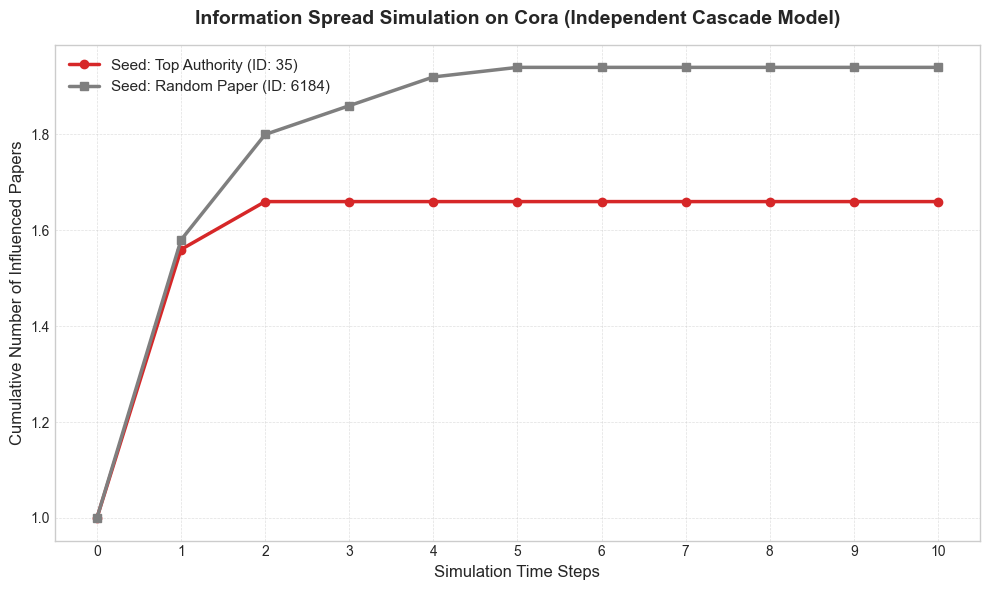

In [37]:
# Scenario A: Top Authority (High-influence node found in previous steps)
top_authority = max(dict(G.in_degree()).items(), key=lambda x: x[1])[0]

# Scenario B: Random Paper (Average-influence node)
np.random.seed(42)
random_node = np.random.choice(list(G.nodes()))

# --- 1. Define Seed Nodes for Comparison ---


# --- 2. Run Multiple Simulations to Get Stable Averages ---
num_runs = 50
steps = 10
prob = 0.20 # 20% chance of spreading the idea per link

auth_spread_runs = np.array([simulate_independent_cascade(G, [top_authority], prob, steps) for _ in range(num_runs)])
rand_spread_runs = np.array([simulate_independent_cascade(G, [random_node], prob, steps) for _ in range(num_runs)])

# Calculate mean cascade curves
auth_mean_curve = np.mean(auth_spread_runs, axis=0)
rand_mean_curve = np.mean(rand_spread_runs, axis=0)

# --- 3. Plot the Information Spread Curves ---
plt.figure(figsize=(10, 6))
plt.plot(auth_mean_curve, marker='o', linewidth=2.5, color='#d62728', label=f'Seed: Top Authority (ID: {top_authority})')
plt.plot(rand_mean_curve, marker='s', linewidth=2.5, color='#7f7f7f', label=f'Seed: Random Paper (ID: {random_node})')

plt.title('Information Spread Simulation on Cora (Independent Cascade Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Simulation Time Steps', fontsize=12)
plt.ylabel('Cumulative Number of Influenced Papers', fontsize=12)
plt.xticks(range(steps + 1))
plt.grid(True, ls='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

plt.show()

## Visualizzazione

### JSON generation...

In [38]:
# Calcolo metriche necessarie per la visualizzazione
pagerank_scores = nx.pagerank(G)
in_degrees = dict(G.in_degree())

# Community Detection (Louvain) per il filtro di confronto
G_und = G.to_undirected()
louvain_partition = nx_comm.louvain_communities(G_und, seed=42)
node_comm_map = {node: i for i, comm in enumerate(louvain_partition) for node in comm}

d3_data = {"nodes": [], "links": []}

for node in G.nodes():
    d3_data["nodes"].append({
        "id": int(node),
        "field": G.nodes[node].get("field", "Unknown"),
        "community": int(node_comm_map.get(node, 0)),
        "pagerank": float(pagerank_scores.get(node, 0)),
        "in_degree": int(in_degrees.get(node, 0))
    })

for u, v in G.edges():
    # Calcolo rapido del Neighborhood Overlap per marcare i Local Bridges
    nu = set(G_und.neighbors(u))
    nv = set(G_und.neighbors(v))
    union_size = len(nu.union(nv)) - 2
    overlap = len(nu.intersection(nv)) / union_size if union_size > 0 else 0.0

    d3_data["links"].append({
        "source": int(u),
        "target": int(v),
        "is_local_bridge": bool(overlap == 0.0),
        "is_cross_field": bool(G.nodes[u].get("field") != G.nodes[v].get("field"))
    })

with open("cora_d3_data.json", "w") as f:
    json.dump(d3_data, f, indent=2)

print("✅ 'cora_d3_data.json' generato con successo!")

✅ 'cora_d3_data.json' generato con successo!


### Server Launching

In [39]:

PORT = 8000

# Funzione per inizializzare il server
def start_server():
    # Allow port reuse to avoid 'Address already in use' errors on quick restarts
    socketserver.TCPServer.allow_reuse_address = True
    Handler = http.server.SimpleHTTPRequestHandler

    with socketserver.TCPServer(("", PORT), Handler) as httpd:
        print(f"🌍 Server D3 attivo in background sulla porta {PORT}.")
        print("Puoi continuare a usare il notebook liberamente.")
        httpd.serve_forever()

# Lanciamo il server dentro un Thread asincrono separato
server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

# Apre automaticamente una nuova tab nel tuo browser predefinito all'indirizzo corretto
webbrowser.open(f'http://localhost:{PORT}/index.html')

🌍 Server D3 attivo in background sulla porta 8000.
Puoi continuare a usare il notebook liberamente.


True

127.0.0.1 - - [17/May/2026 08:00:59] "GET /index.html HTTP/1.1" 200 -
----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 63297)
Traceback (most recent call last):
  File "C:\Users\loryp\AppData\Local\Programs\Python\Python314\Lib\socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\loryp\AppData\Local\Programs\Python\Python314\Lib\socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\loryp\AppData\Local\Programs\Python\Python314\Lib\socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\loryp\AppData\Local\Programs\Python\Python314\Lib\http\server.py", line 721, in __init__
    sup